# Performance vs. reasoning budget (cap)

How does downstream accuracy change as we shrink the reasoning budget
(`max_thinking_tokens`) at evaluation time?

Results live under
`artifacts/distillation_on_synthetic_traces/mmlu/direct_reasoning_trace/<variant>/`.
Each variant dir holds one summary per cap:

- `summary_reasoning_evals.json` &rarr; default cap **8192** (inner key `mmlu_random_test`)
- `summary_reasoning_evals_cap<N>.json` &rarr; cap **N** (inner key `mmlu_random_test_cap<N>`)

The cap is parsed from the filename. **Only variants evaluated at &ge; 2 distinct
caps are kept**, so this notebook shows exactly the experiments where the reasoning
budget actually varies. The headline metric per (variant, cap) is the
**best-checkpoint accuracy** (max over epochs); accuracy-vs-epoch curves are shown
for context. Scope is discovered from the directory tree, so re-running picks up
newly finished runs.


In [1]:
import json
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


def find_artifacts_dir(start: Path | None = None) -> Path:
    """Walk up from `start` (cwd by default) until an `artifacts/` dir is found."""
    start = (start or Path.cwd()).resolve()
    for d in [start, *start.parents]:
        if (d / "artifacts").is_dir():
            return d / "artifacts"
    raise FileNotFoundError("artifacts/ not found above cwd")


ARTIFACTS = find_artifacts_dir()
ROOT = ARTIFACTS.parent
if str(ROOT / "src") not in sys.path:  # make `core.*` importable when run top-to-bottom
    sys.path.insert(0, str(ROOT / "src"))

from core.utils.graph_style import set_style  # noqa: E402

set_style()

GROUP = "distillation_on_synthetic_traces"
DATASET = "mmlu"
SUBGROUP = "direct_reasoning_trace"
METRIC = "accuracy"
DEFAULT_CAP = 8192
SAVE = True  # also write PNGs/CSVs under artifacts/<group>/<dataset>/plots/

SUBGROUP_DIR = ARTIFACTS / GROUP / DATASET / SUBGROUP
PLOTS_DIR = ARTIFACTS / GROUP / DATASET / "plots"
if SAVE:
    PLOTS_DIR.mkdir(parents=True, exist_ok=True)
SUBGROUP_DIR


PosixPath('/Users/aigoncharov/dev/sktech/recursive_caft/artifacts/distillation_on_synthetic_traces/mmlu/direct_reasoning_trace')

In [2]:
SUMMARY_GLOB = "summary_reasoning_evals*.json"
CAP_RE = re.compile(r"summary_reasoning_evals(?:_cap(\d+))?\.json$")


def load_cap_curves(subgroup_dir: Path) -> dict:
    """variant -> cap -> sorted [(epoch, accuracy, num_truncated, total)].

    The cap is parsed from the summary filename (bare file == DEFAULT_CAP). Each
    summary holds exactly one eval-key. Only variants evaluated at >= 2 distinct
    caps are kept -> exactly the experiments where the reasoning budget varies.
    """
    curves: dict = {}
    for variant_dir in sorted(subgroup_dir.iterdir()):
        if not variant_dir.is_dir():
            continue
        per_cap: dict = {}
        for summary in sorted(variant_dir.glob(SUMMARY_GLOB)):
            m = CAP_RE.search(summary.name)
            if not m:
                continue
            cap = int(m.group(1)) if m.group(1) else DEFAULT_CAP
            content = json.loads(summary.read_text())
            records = next(iter(content.values()))  # single eval-key per file
            points = sorted(
                (r["epoch"], r[METRIC], r.get("num_truncated"), r.get("total"))
                for r in records
                if r.get("epoch") is not None and r.get(METRIC) is not None
            )
            if points:
                per_cap[cap] = points
        if len(per_cap) >= 2:
            curves[variant_dir.name] = dict(sorted(per_cap.items()))
    return curves


cap_curves = load_cap_curves(SUBGROUP_DIR)

print(f"Variants with >= 2 caps ({len(cap_curves)}):")
for variant, per_cap in cap_curves.items():
    print(f"  {variant}: caps {sorted(per_cap)}")


Variants with >= 2 caps (8):
  llama_3b_head_truncated24000: caps [1024, 2048, 4096, 8192]
  llama_3b_head_truncated3072: caps [2048, 4096]
  llama_3b_head_truncated8192: caps [1024, 2048, 4096, 8192]
  phi4_mini_head_truncated24000: caps [2048, 4096, 8192]
  phi4_mini_head_truncated3072: caps [1024, 2048, 4096]
  phi4_mini_head_truncated8192: caps [1024, 2048, 4096, 8192]
  qwen_3b_head_truncated24000: caps [1024, 2048, 4096, 8192]
  qwen_3b_head_truncated8192: caps [1024, 2048, 4096, 8192]


In [3]:
rows = []
for variant, per_cap in cap_curves.items():
    for cap, points in per_cap.items():
        best_epoch, best_acc, best_trunc, best_total = max(points, key=lambda p: p[1])
        rows.append(
            {
                "variant": variant,
                "cap": cap,
                "best_acc": best_acc,
                "epoch_at_best": best_epoch,
                "num_truncated_at_best": best_trunc,
                "total": best_total,
                "trunc_rate_at_best": (best_trunc / best_total)
                if best_total
                else np.nan,
            }
        )

best_df = pd.DataFrame(rows).sort_values(["variant", "cap"]).reset_index(drop=True)
if SAVE:
    best_df.to_csv(PLOTS_DIR / "cap_best_checkpoint.csv", index=False)
best_df


,variant,cap,best_acc,epoch_at_best,num_truncated_at_best,total,trunc_rate_at_best
0,llama_3b_head_truncated24000,1024,0.446384,20.0,7,2406,0.002909
1,llama_3b_head_truncated24000,2048,0.456359,5.0,3,2406,0.001247
2,llama_3b_head_truncated24000,4096,0.462594,15.0,1,2406,0.000416
3,llama_3b_head_truncated24000,8192,0.459268,20.0,2,2406,0.000831
4,llama_3b_head_truncated3072,2048,0.481297,5.0,0,2406,0.000000
5,llama_3b_head_truncated3072,4096,0.476309,10.0,0,2406,0.000000
6,llama_3b_head_truncated8192,1024,0.463425,5.0,0,2406,0.000000
7,llama_3b_head_truncated8192,2048,0.468412,5.0,0,2406,0.000000
8,llama_3b_head_truncated8192,4096,0.463009,15.0,0,2406,0.000000
9,llama_3b_head_truncated8192,8192,0.481297,10.0,0,2406,0.000000


In [4]:
# Same table, but at each variant's *last* checkpoint (max epoch) rather than the
# best one. Lets us compare the headline / truncation figures under "just take the
# final model" against the best-checkpoint view above.
last_rows = []
for variant, per_cap in cap_curves.items():
    for cap, points in per_cap.items():
        last_epoch, last_acc, last_trunc, last_total = max(points, key=lambda p: p[0])
        last_rows.append(
            {
                "variant": variant,
                "cap": cap,
                "last_acc": last_acc,
                "epoch_at_last": last_epoch,
                "num_truncated_at_last": last_trunc,
                "total": last_total,
                "trunc_rate_at_last": (last_trunc / last_total)
                if last_total
                else np.nan,
            }
        )

last_df = pd.DataFrame(last_rows).sort_values(["variant", "cap"]).reset_index(drop=True)
if SAVE:
    last_df.to_csv(PLOTS_DIR / "cap_last_checkpoint.csv", index=False)
last_df


,variant,cap,last_acc,epoch_at_last,num_truncated_at_last,total,trunc_rate_at_last
0,llama_3b_head_truncated24000,1024,0.446384,20.0,7,2406,0.002909
1,llama_3b_head_truncated24000,2048,0.452618,20.0,2,2406,0.000831
2,llama_3b_head_truncated24000,4096,0.455528,20.0,0,2406,0.000000
3,llama_3b_head_truncated24000,8192,0.459268,20.0,2,2406,0.000831
4,llama_3b_head_truncated3072,2048,0.459684,20.0,0,2406,0.000000
5,llama_3b_head_truncated3072,4096,0.472569,20.0,0,2406,0.000000
6,llama_3b_head_truncated8192,1024,0.441397,20.0,4,2406,0.001663
7,llama_3b_head_truncated8192,2048,0.455528,20.0,1,2406,0.000416
8,llama_3b_head_truncated8192,4096,0.460931,20.0,0,2406,0.000000
9,llama_3b_head_truncated8192,8192,0.464256,20.0,0,2406,0.000000


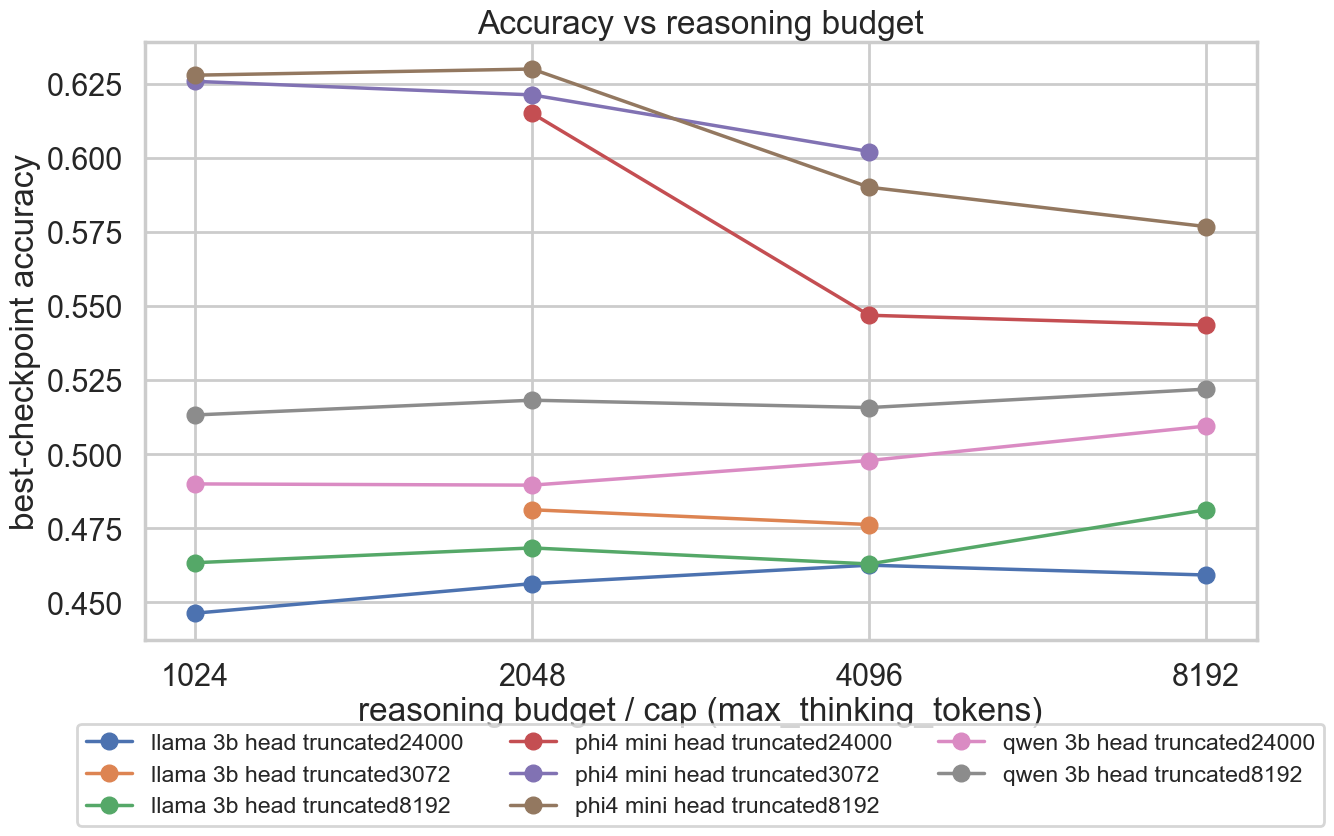

In [5]:
caps_sorted = sorted(best_df["cap"].unique())

fig, ax = plt.subplots(figsize=(14, 9))
for variant in sorted(cap_curves):
    sub = best_df[best_df["variant"] == variant].sort_values("cap")
    ax.plot(sub["cap"], sub["best_acc"], marker="o", lw=2.5,
            label=variant.replace("_", " "))
ax.set_xscale("log", base=2)
ax.set_xticks(caps_sorted)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xlabel("reasoning budget / cap (max_thinking_tokens)")
ax.set_ylabel("best-checkpoint accuracy")
ax.set_title("Accuracy vs reasoning budget")
ax.legend(fontsize="x-small", loc="upper center", bbox_to_anchor=(0.5, -0.12),
          ncol=3)
fig.tight_layout()
if SAVE:
    fig.savefig(PLOTS_DIR / "cap_best_acc_vs_cap.png", dpi=150, bbox_inches="tight")
plt.show()


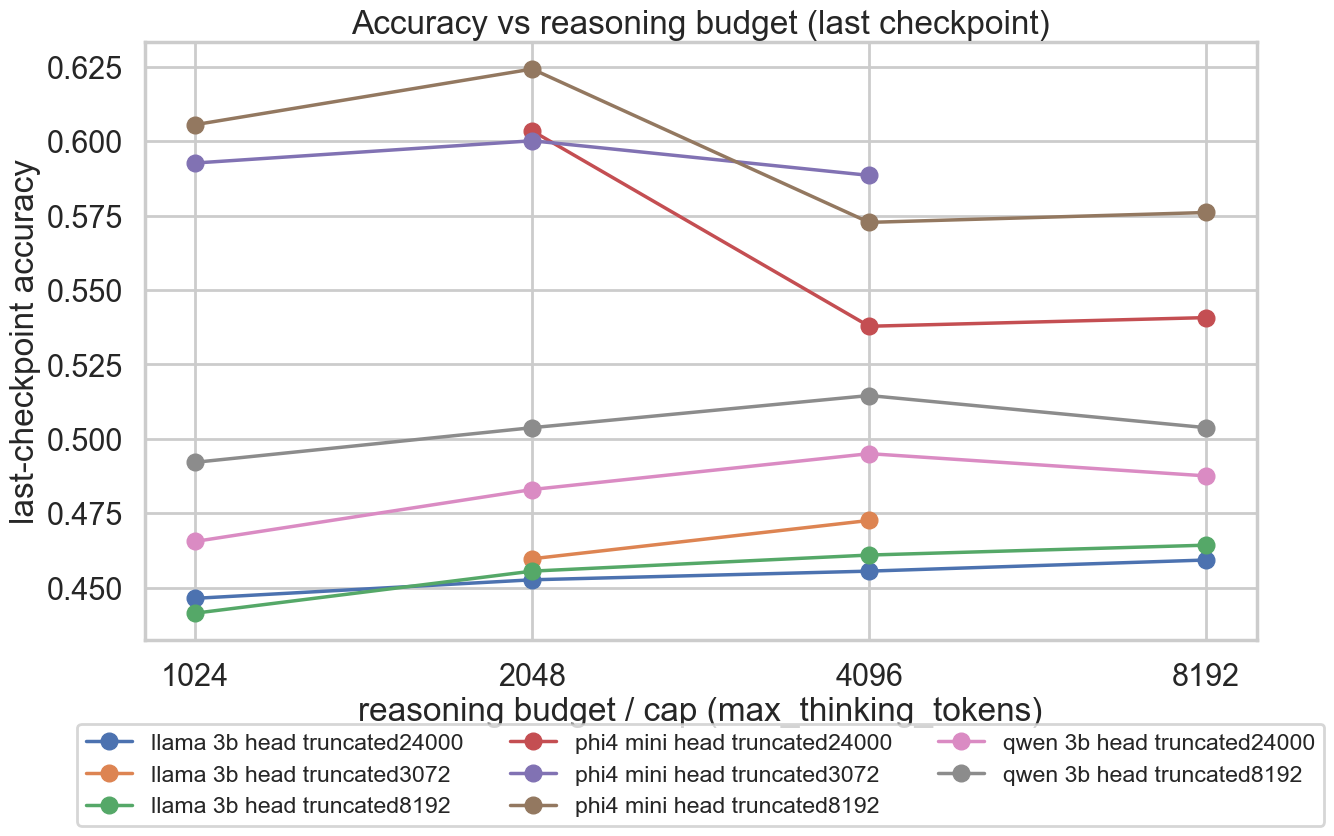

In [6]:
# Same headline figure, but reading each point off the *last* checkpoint.
fig, ax = plt.subplots(figsize=(14, 9))
for variant in sorted(cap_curves):
    sub = last_df[last_df["variant"] == variant].sort_values("cap")
    ax.plot(sub["cap"], sub["last_acc"], marker="o", lw=2.5,
            label=variant.replace("_", " "))
ax.set_xscale("log", base=2)
ax.set_xticks(caps_sorted)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xlabel("reasoning budget / cap (max_thinking_tokens)")
ax.set_ylabel("last-checkpoint accuracy")
ax.set_title("Accuracy vs reasoning budget (last checkpoint)")
ax.legend(fontsize="x-small", loc="upper center", bbox_to_anchor=(0.5, -0.12),
          ncol=3)
fig.tight_layout()
if SAVE:
    fig.savefig(PLOTS_DIR / "cap_last_acc_vs_cap.png", dpi=150, bbox_inches="tight")
plt.show()


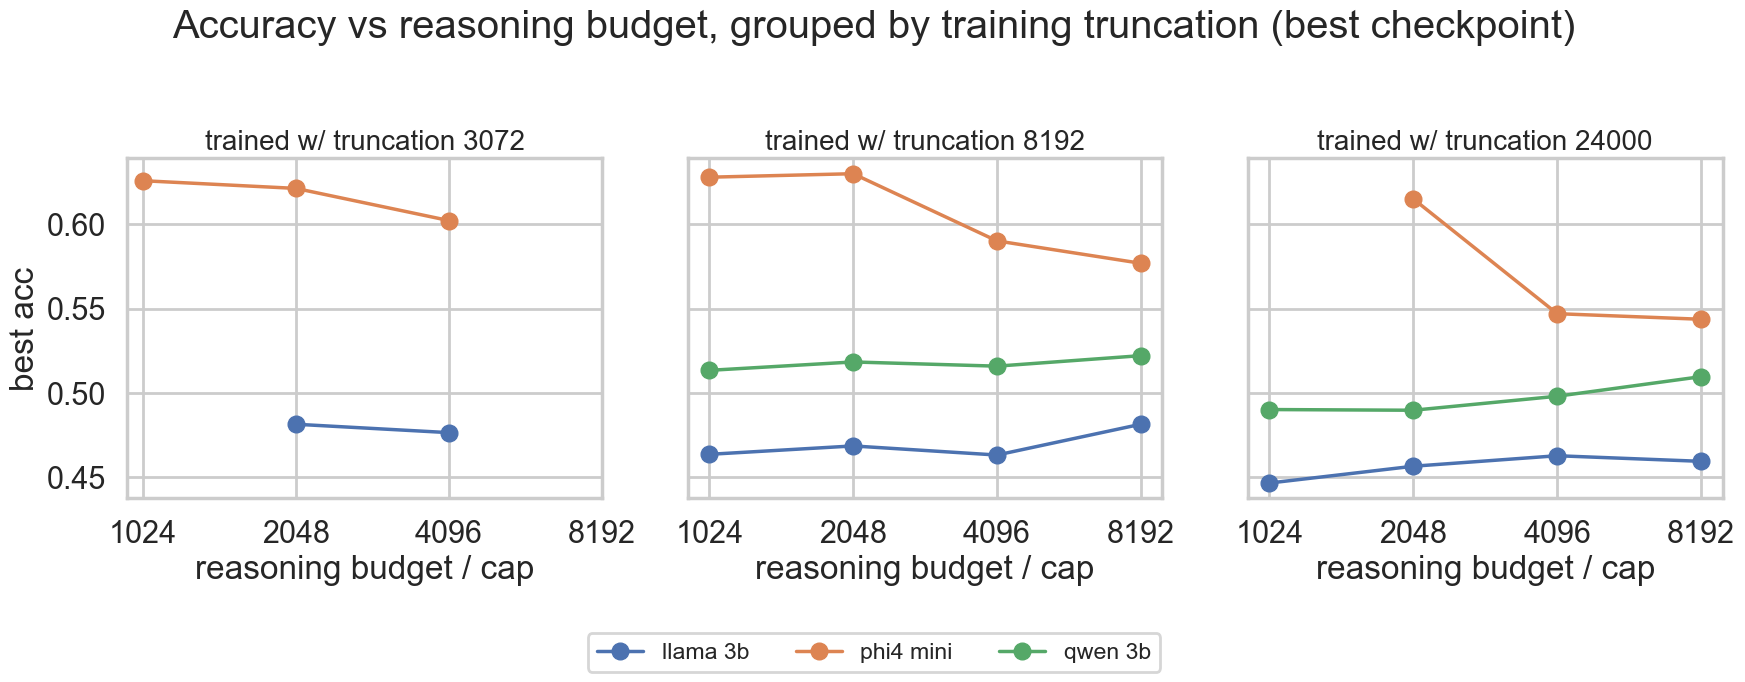

In [7]:
# Same headline figure, but faceted by *training truncation length* so models can be
# compared directly at each setting. Variant names are `<model>_<pos>_truncated<N>`;
# the kept variants are all `head`, so we split into model and truncation number and
# put one subplot per truncation N, one line per model.
VARIANT_RE = re.compile(r"^(?P<model>.+?)_(?P<pos>head|middle|tail)_truncated(?P<trunc>\d+)$")


def split_variant(variant: str) -> tuple[str, int]:
    """`llama_3b_head_truncated8192` -> ("llama_3b", 8192)."""
    m = VARIANT_RE.match(variant)
    if not m:
        raise ValueError(f"unrecognised variant name: {variant}")
    return m.group("model"), int(m.group("trunc"))


def plot_acc_by_truncation(df: pd.DataFrame, acc_col: str, title: str, fname: str):
    """One subplot per training-truncation length; one line per model within each."""
    d = df.copy()
    d[["model", "trunc"]] = [split_variant(v) for v in d["variant"]]
    truncs = sorted(d["trunc"].unique())
    models = sorted(d["model"].unique())
    colors = {m: c for m, c in zip(models, plt.rcParams["axes.prop_cycle"].by_key()["color"])}

    fig, axes = plt.subplots(1, len(truncs), figsize=(6 * len(truncs), 6),
                             squeeze=False, sharey=True)
    for ax, trunc in zip(axes.flat, truncs):
        for model in models:
            sub = d[(d["trunc"] == trunc) & (d["model"] == model)].sort_values("cap")
            if sub.empty:
                continue
            ax.plot(sub["cap"], sub[acc_col], marker="o", lw=2.5,
                    color=colors[model], label=model.replace("_", " "))
        ax.set_xscale("log", base=2)
        ax.set_xticks(caps_sorted)
        ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
        ax.set_title(f"trained w/ truncation {trunc}", fontsize="small")
        ax.set_xlabel("reasoning budget / cap")
    axes.flat[0].set_ylabel(acc_col.replace("_", " "))
    # One shared legend below all subplots (models repeat identically across them).
    handles = [plt.Line2D([], [], color=colors[m], marker="o", lw=2.5,
                          label=m.replace("_", " ")) for m in models]
    fig.legend(handles=handles, fontsize="x-small", loc="upper center",
               bbox_to_anchor=(0.5, 0.0), ncol=len(models))
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    if SAVE:
        fig.savefig(PLOTS_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()


plot_acc_by_truncation(
    best_df, "best_acc",
    "Accuracy vs reasoning budget, grouped by training truncation (best checkpoint)",
    "cap_best_acc_vs_cap_by_truncation.png",
)


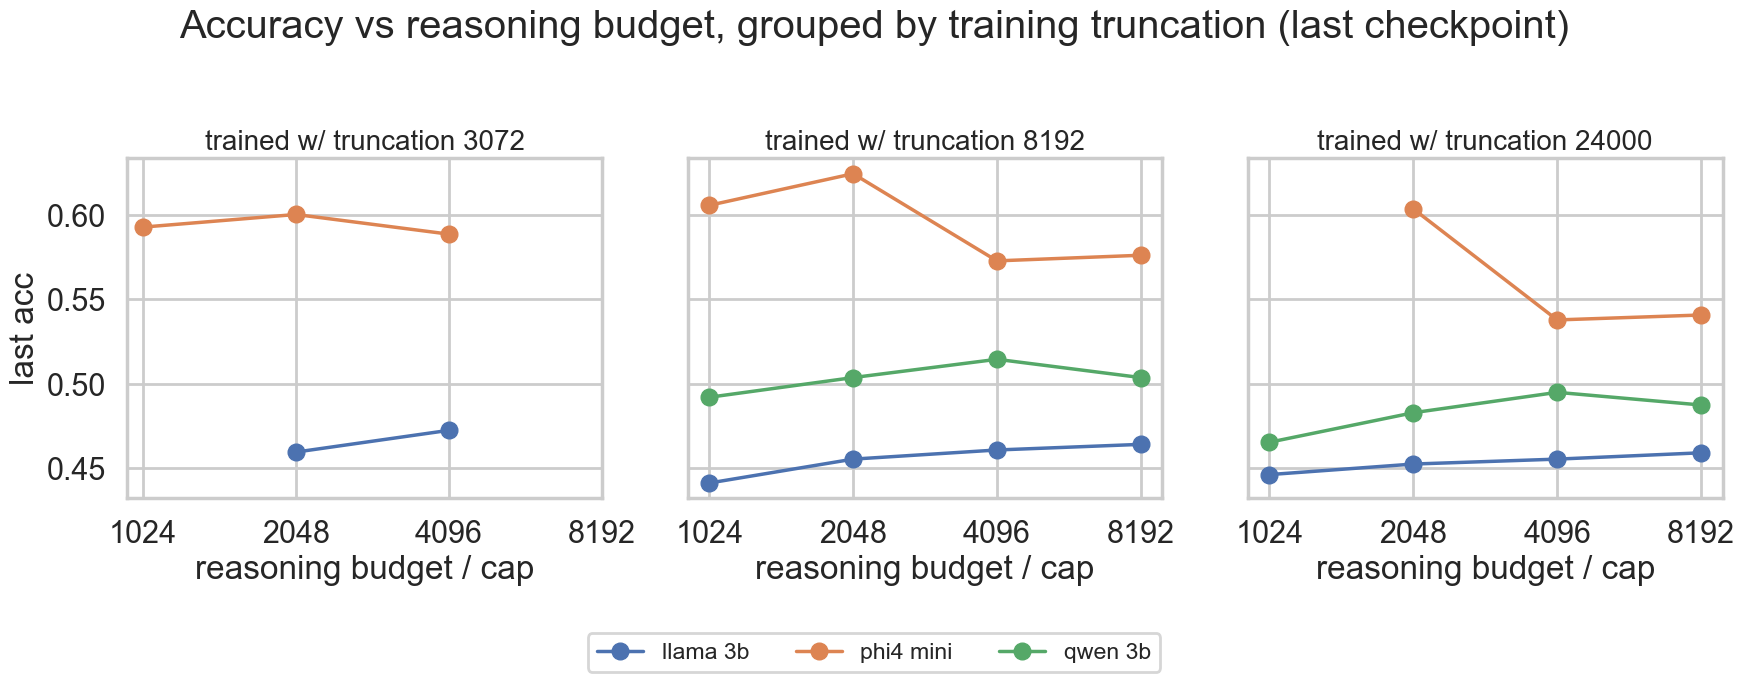

In [8]:
# Same grouped-by-truncation view, at the last checkpoint.
plot_acc_by_truncation(
    last_df, "last_acc",
    "Accuracy vs reasoning budget, grouped by training truncation (last checkpoint)",
    "cap_last_acc_vs_cap_by_truncation.png",
)


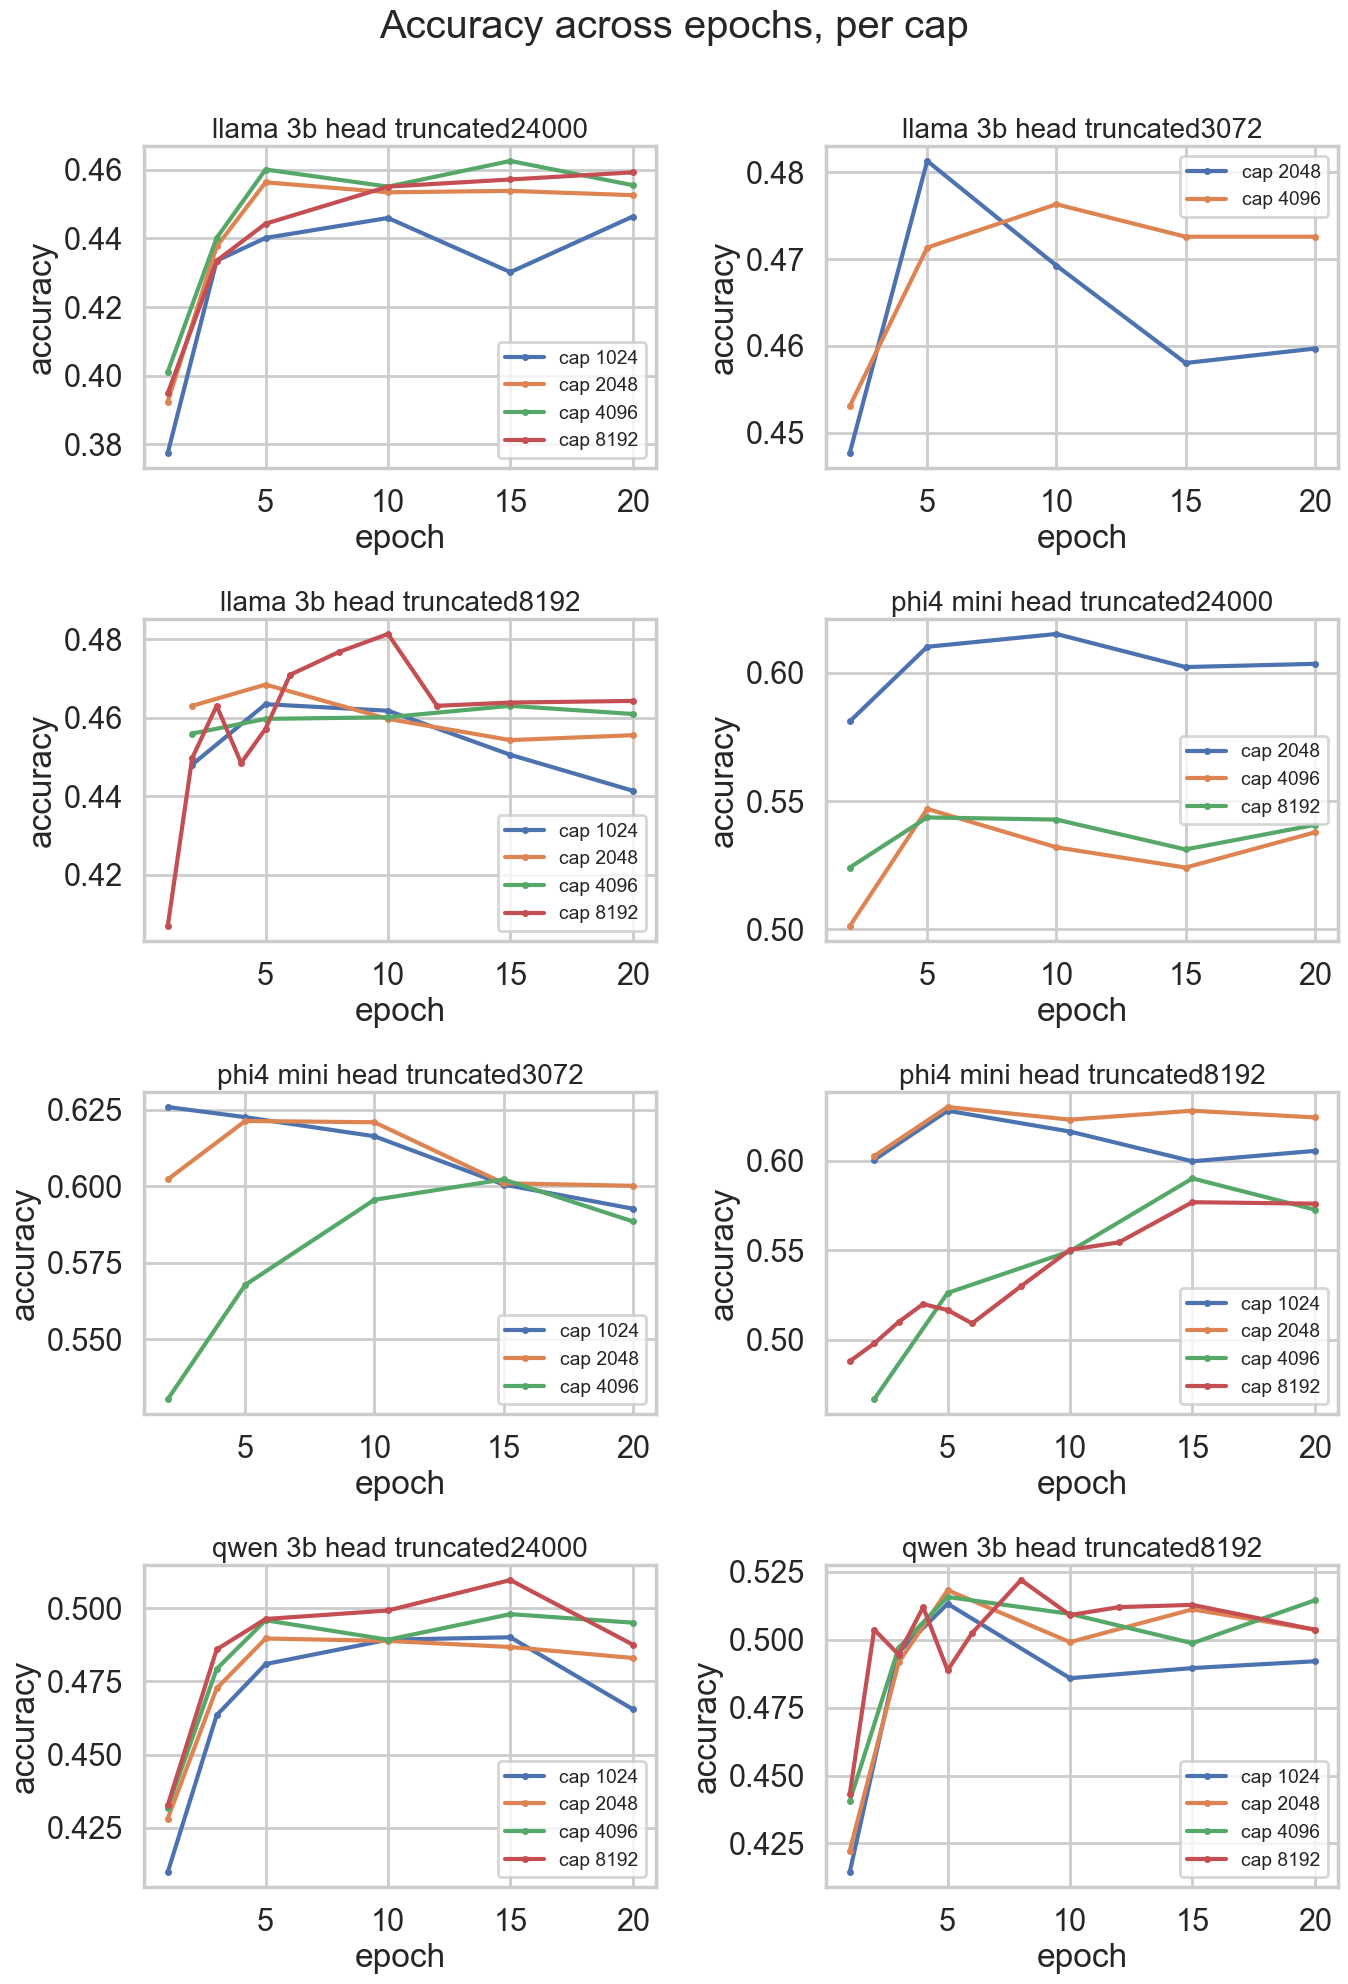

In [9]:
variants = sorted(cap_curves)
ncols = 2
nrows = int(np.ceil(len(variants) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows), squeeze=False)
for ax, variant in zip(axes.flat, variants):
    for cap, points in cap_curves[variant].items():
        xs = [e for e, *_ in points]
        ys = [a for _, a, *_ in points]
        ax.plot(xs, ys, marker="o", ms=4, label=f"cap {cap}")
    ax.set_title(variant.replace("_", " "), fontsize="small")
    ax.set_xlabel("epoch")
    ax.set_ylabel(METRIC)
    ax.legend(fontsize="xx-small", loc="best")
for ax in axes.flat[len(variants):]:
    ax.set_visible(False)
fig.suptitle("Accuracy across epochs, per cap", y=1.0)
fig.tight_layout()
if SAVE:
    fig.savefig(PLOTS_DIR / "cap_accuracy_vs_epoch.png", dpi=150, bbox_inches="tight")
plt.show()


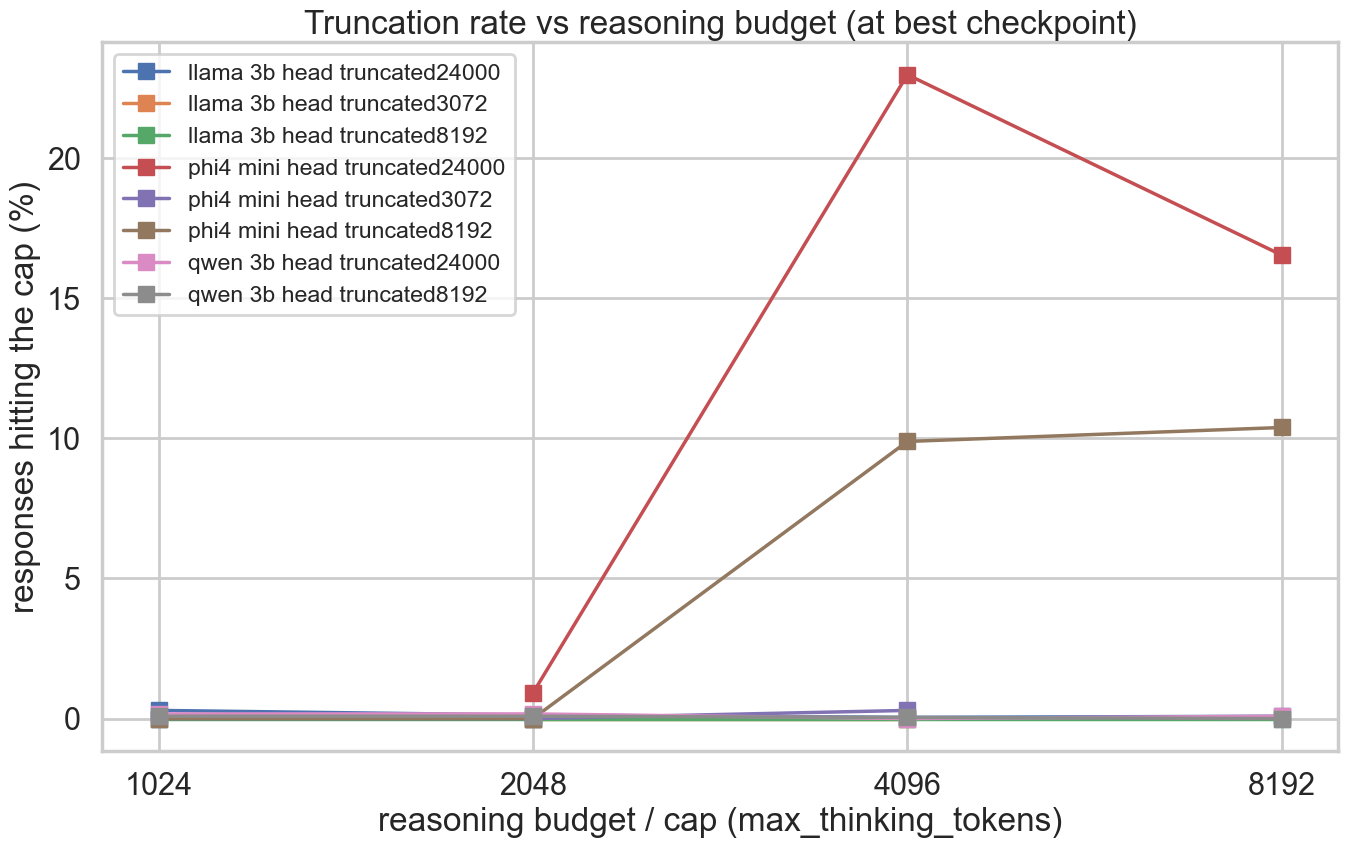

In [10]:
# Mechanism: lower caps force more responses to hit the budget (truncation),
# which is what drags accuracy down. Rate measured at each variant's best checkpoint.
fig, ax = plt.subplots(figsize=(14, 9))
for variant in sorted(cap_curves):
    sub = best_df[best_df["variant"] == variant].sort_values("cap")
    ax.plot(sub["cap"], 100 * sub["trunc_rate_at_best"], marker="s", lw=2.5,
            label=variant.replace("_", " "))
ax.set_xscale("log", base=2)
ax.set_xticks(caps_sorted)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xlabel("reasoning budget / cap (max_thinking_tokens)")
ax.set_ylabel("responses hitting the cap (%)")
ax.set_title("Truncation rate vs reasoning budget (at best checkpoint)")
ax.legend(fontsize="x-small", loc="best")
fig.tight_layout()
if SAVE:
    fig.savefig(PLOTS_DIR / "cap_truncation_rate_vs_cap.png", dpi=150, bbox_inches="tight")
plt.show()


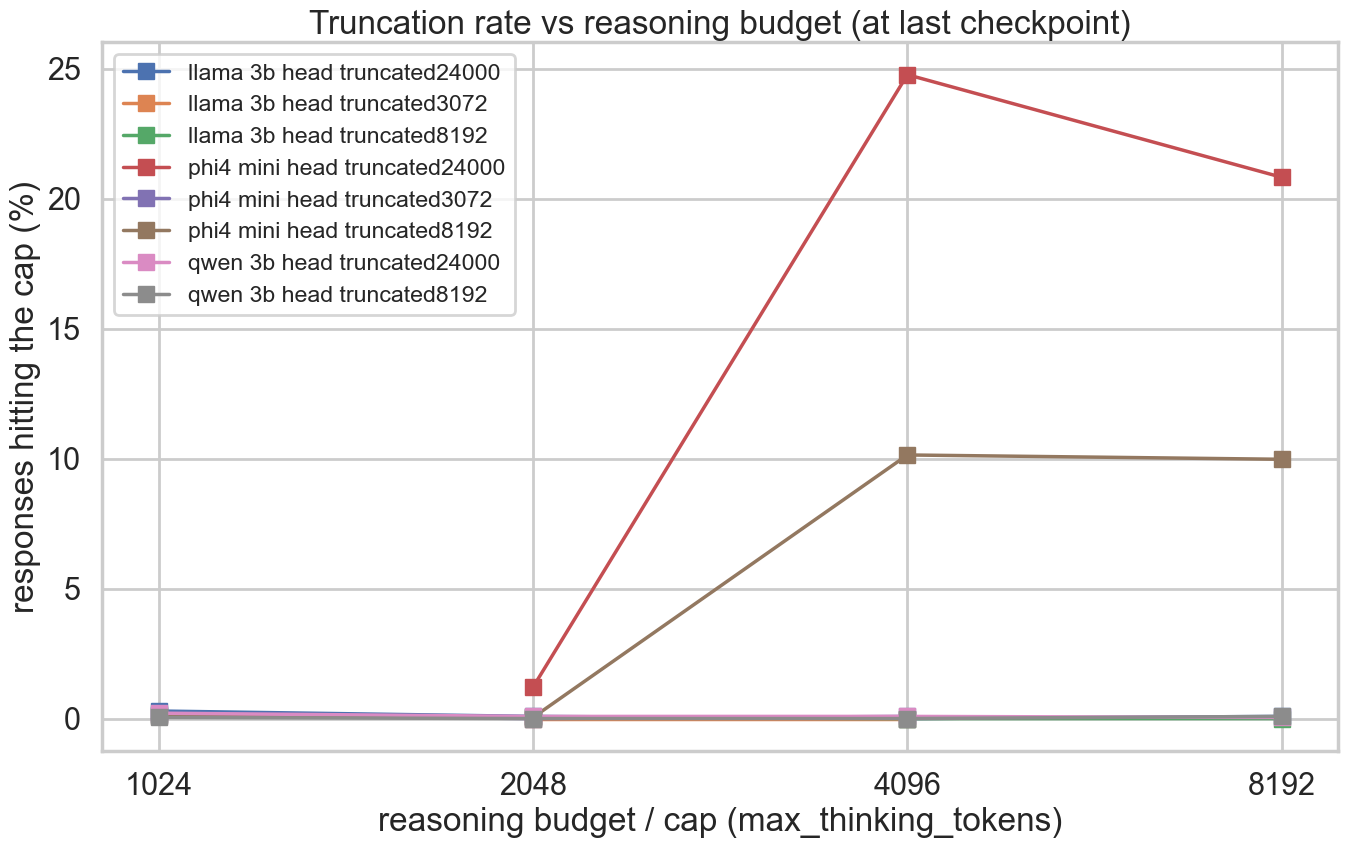

In [11]:
# Same mechanism figure, measured at each variant's last checkpoint instead.
fig, ax = plt.subplots(figsize=(14, 9))
for variant in sorted(cap_curves):
    sub = last_df[last_df["variant"] == variant].sort_values("cap")
    ax.plot(sub["cap"], 100 * sub["trunc_rate_at_last"], marker="s", lw=2.5,
            label=variant.replace("_", " "))
ax.set_xscale("log", base=2)
ax.set_xticks(caps_sorted)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xlabel("reasoning budget / cap (max_thinking_tokens)")
ax.set_ylabel("responses hitting the cap (%)")
ax.set_title("Truncation rate vs reasoning budget (at last checkpoint)")
ax.legend(fontsize="x-small", loc="best")
fig.tight_layout()
if SAVE:
    fig.savefig(PLOTS_DIR / "cap_last_truncation_rate_vs_cap.png", dpi=150, bbox_inches="tight")
plt.show()


In [12]:
# Accuracy change from the smallest to the largest available cap, per variant.
summary = []
for variant, per_cap in cap_curves.items():
    caps = sorted(per_cap)
    lo, hi = caps[0], caps[-1]
    acc_lo = best_df.query("variant == @variant and cap == @lo")["best_acc"].iloc[0]
    acc_hi = best_df.query("variant == @variant and cap == @hi")["best_acc"].iloc[0]
    summary.append(
        {
            "variant": variant,
            "cap_low": lo,
            "cap_high": hi,
            "acc_low": acc_lo,
            "acc_high": acc_hi,
            "delta_acc_high_minus_low": acc_hi - acc_lo,
        }
    )
summary_df = (
    pd.DataFrame(summary)
    .sort_values("delta_acc_high_minus_low", ascending=False)
    .reset_index(drop=True)
)
summary_df


,variant,cap_low,cap_high,acc_low,acc_high,delta_acc_high_minus_low
0,qwen_3b_head_truncated24000,1024,8192,0.490025,0.509559,0.019534
1,llama_3b_head_truncated8192,1024,8192,0.463425,0.481297,0.017872
2,llama_3b_head_truncated24000,1024,8192,0.446384,0.459268,0.012884
3,qwen_3b_head_truncated8192,1024,8192,0.513300,0.522028,0.008728
4,llama_3b_head_truncated3072,2048,4096,0.481297,0.476309,-0.004988
5,phi4_mini_head_truncated3072,1024,4096,0.625935,0.602244,-0.023691
6,phi4_mini_head_truncated8192,1024,8192,0.628013,0.576891,-0.051122
7,phi4_mini_head_truncated24000,2048,8192,0.615129,0.543641,-0.071488


## Takeaways

- Read the **first figure** as the headline: best-checkpoint accuracy against the
  reasoning budget (cap) for every variant that was swept over multiple caps.
- The **per-cap epoch curves** show whether a smaller budget merely converges to a
  lower plateau or also destabilises training.
- The **truncation-rate figure** explains the mechanism: as the cap shrinks, a
  larger share of responses get cut off before the answer, which is what erodes
  accuracy. Variants trained on longer traces (`*_truncated24000`) hit the cap
  harder at small budgets.
- The **delta table** quantifies the accuracy gained by going from each variant's
  smallest to its largest available cap.
